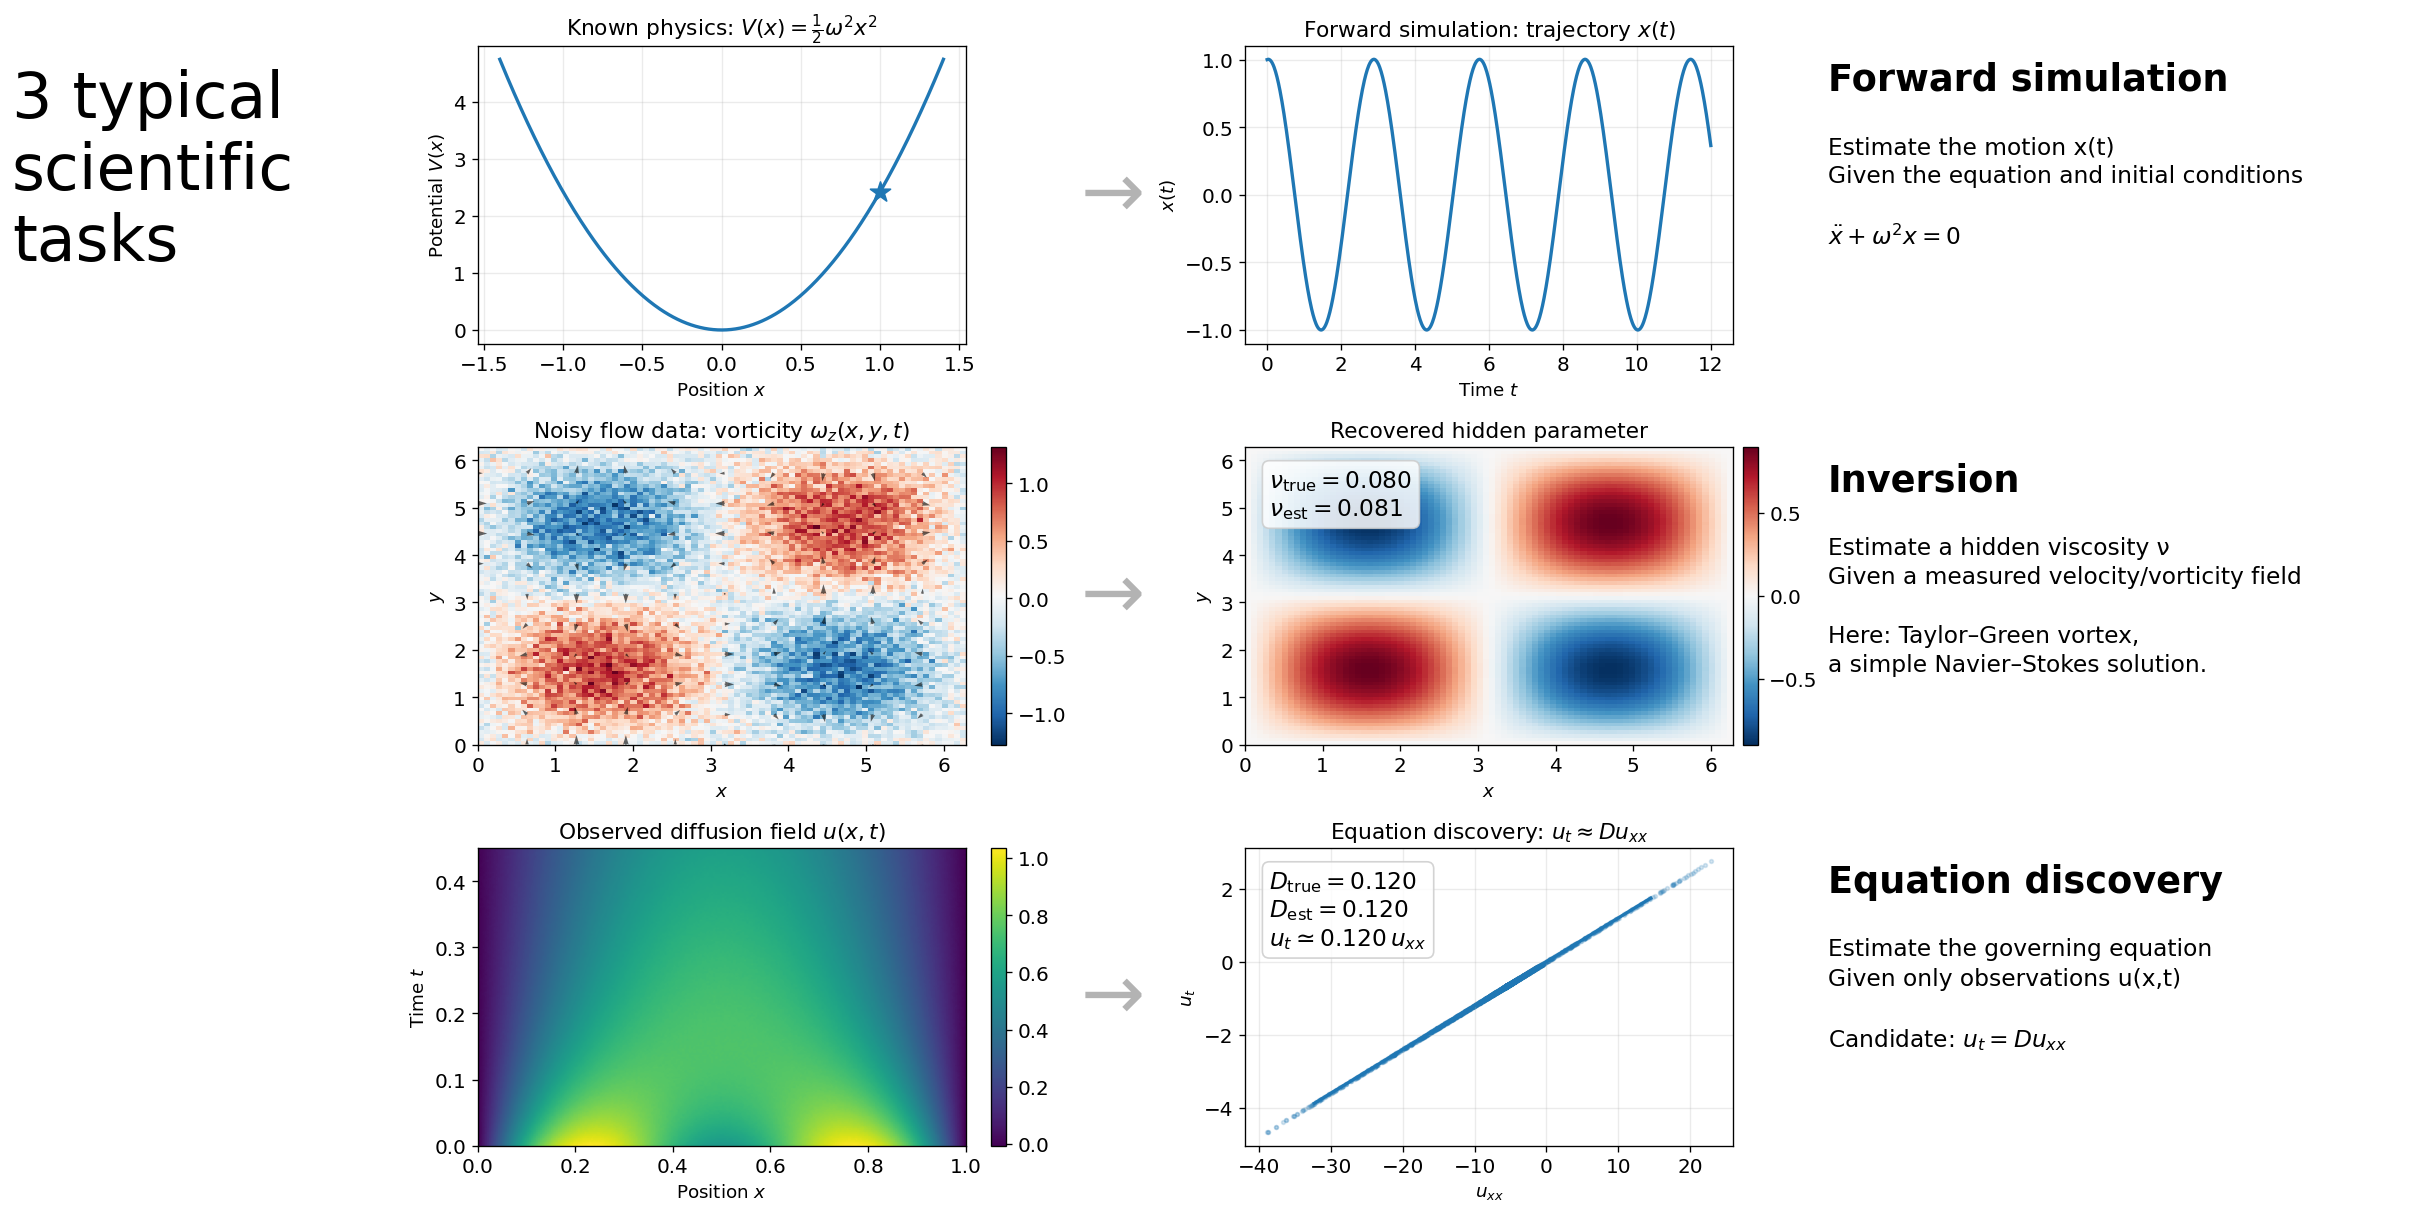

Figure saved as: three_scientific_tasks_my_way.png
Estimated viscosity nu = 0.0807
Estimated diffusion coefficient D = 0.1201


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


# FIGURE : 3 TYPICAL SCIENTIFIC TASKS — VERSION PHYSIQUE

def make_three_tasks_figure(save_path="three_scientific_tasks_my_way.png"):

    rng = np.random.default_rng(4)

    plt.rcParams.update({
        "font.size": 12,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "figure.dpi": 120
    })

   

    omega = 2.2
    x0 = 1.0
    v0 = 0.15

    t_osc = np.linspace(0, 12, 900)

    x_osc = x0 * np.cos(omega * t_osc) + (v0 / omega) * np.sin(omega * t_osc)

    x_grid = np.linspace(-1.4, 1.4, 400)
    V_potential = 0.5 * omega**2 * x_grid**2

    

    nu_true = 0.08
    t0 = 0.0
    t1 = 5.0

    n = 80
    X = np.linspace(0, 2 * np.pi, n)
    Y = np.linspace(0, 2 * np.pi, n)
    XX, YY = np.meshgrid(X, Y)

    base_vort = 2 * np.sin(XX) * np.sin(YY)

    def velocity_and_vorticity(time, nu):
        decay = np.exp(-2 * nu * time)

        U = -np.cos(XX) * np.sin(YY) * decay
        V =  np.sin(XX) * np.cos(YY) * decay
        W = base_vort * decay

        return U, V, W

    U0, V0, W0 = velocity_and_vorticity(t0, nu_true)
    U1, V1, W1 = velocity_and_vorticity(t1, nu_true)

    noise_level = 0.18
    W0_noisy = W0 + noise_level * rng.normal(size=W0.shape)
    W1_noisy = W1 + noise_level * rng.normal(size=W1.shape)

    # Estimation de la viscosité par décroissance de l'amplitude :
    #
    # W(t) = base * exp(-2 nu t)
    #
    # Donc si on estime l'amplitude à t0 et t1 :
    #
    # nu = - ln(A1/A0) / (2 (t1 - t0))

    amp0 = np.sum(W0_noisy * base_vort) / np.sum(base_vort**2)
    amp1 = np.sum(W1_noisy * base_vort) / np.sum(base_vort**2)

    nu_est = -np.log(amp1 / amp0) / (2 * (t1 - t0))

    
    # 3) EQUATION DISCOVERY : DIFFUSION
    # Données u(x,t) -> retrouver u_t = D u_xx

    D_true = 0.12

    nx = 220
    nt = 150

    x = np.linspace(0, 1, nx)
    tt = np.linspace(0, 0.45, nt)

    XXd, TTd = np.meshgrid(x, tt)

    U_diff = (
        np.exp(-D_true * np.pi**2 * TTd) * np.sin(np.pi * XXd)
        + 0.45 * np.exp(-D_true * (3 * np.pi)**2 * TTd) * np.sin(3 * np.pi * XXd)
    )

    U_diff_noisy = U_diff + 0.002 * rng.normal(size=U_diff.shape)

    # Dérivées numériques
    dt = tt[1] - tt[0]
    dx = x[1] - x[0]

    Ut = np.gradient(U_diff, dt, axis=0)
    Ux = np.gradient(U_diff, dx, axis=1)
    Uxx = np.gradient(Ux, dx, axis=1)

    # On retire les bords car les dérivées numériques y sont moins fiables.
    Ut_flat = Ut[5:-5, 5:-5].ravel()
    Uxx_flat = Uxx[5:-5, 5:-5].ravel()

    # Fit : Ut ≈ D * Uxx
    D_est = np.sum(Uxx_flat * Ut_flat) / np.sum(Uxx_flat**2)

    idx = rng.choice(len(Uxx_flat), size=2500, replace=False)

    
    # CONSTRUCTION DE LA FIGURE

    fig = plt.figure(figsize=(20, 10), constrained_layout=True)

    gs = GridSpec(
        3, 5,
        figure=fig,
        width_ratios=[1.35, 1.7, 0.25, 1.7, 2.0],
        height_ratios=[1, 1, 1]
    )

    
    # Colonne de gauche : titre général

    ax_left = fig.add_subplot(gs[:, 0])
    ax_left.axis("off")

    ax_left.text(
        0.0, 0.98,
        "3 typical\nscientific\ntasks",
        fontsize=38,
        va="top",
        ha="left"
    )



    
    # LIGNE 1 : FORWARD SIMULATION
    

    ax1_in = fig.add_subplot(gs[0, 1])

    ax1_in.plot(x_grid, V_potential, lw=2)
    ax1_in.scatter(
        [x0],
        [0.5 * omega**2 * x0**2],
        s=160,
        marker="*",
        zorder=5
    )

    ax1_in.set_title(r"Known physics: $V(x)=\frac{1}{2}\omega^2x^2$")
    ax1_in.set_xlabel(r"Position $x$")
    ax1_in.set_ylabel(r"Potential $V(x)$")
    ax1_in.grid(alpha=0.25)

    ax_arrow1 = fig.add_subplot(gs[0, 2])
    ax_arrow1.axis("off")
    ax_arrow1.text(
        0.5, 0.5,
        "→",
        fontsize=46,
        color="0.7",
        ha="center",
        va="center"
    )

    ax1_out = fig.add_subplot(gs[0, 3])

    ax1_out.plot(t_osc, x_osc, lw=2)
    ax1_out.set_title(r"Forward simulation: trajectory $x(t)$")
    ax1_out.set_xlabel(r"Time $t$")
    ax1_out.set_ylabel(r"$x(t)$")
    ax1_out.grid(alpha=0.25)

    ax1_text = fig.add_subplot(gs[0, 4])
    ax1_text.axis("off")

    ax1_text.text(
        0, 0.95,
        "Forward simulation",
        fontsize=22,
        weight="bold",
        ha="left",
        va="top"
    )

    ax1_text.text(
        0, 0.70,
        "Estimate the motion x(t)\n"
        "Given the equation and initial conditions\n\n"
        r"$\ddot{x}+\omega^2x=0$" "\n\n"
        ,
        fontsize=14,
        ha="left",
        va="top",
        linespacing=1.35
    )

    # LIGNE 2 : INVERSION
    

    ax2_in = fig.add_subplot(gs[1, 1])

    im2 = ax2_in.imshow(
        W1_noisy,
        origin="lower",
        extent=[0, 2 * np.pi, 0, 2 * np.pi],
        cmap="RdBu_r",
        aspect="auto"
    )

    step = 8

    ax2_in.quiver(
        XX[::step, ::step],
        YY[::step, ::step],
        U1[::step, ::step],
        V1[::step, ::step],
        color="k",
        alpha=0.6,
        scale=22,
        width=0.004
    )

    ax2_in.set_title(r"Noisy flow data: vorticity $\omega_z(x,y,t)$")
    ax2_in.set_xlabel(r"$x$")
    ax2_in.set_ylabel(r"$y$")

    fig.colorbar(im2, ax=ax2_in, fraction=0.046, pad=0.02)

    ax_arrow2 = fig.add_subplot(gs[1, 2])
    ax_arrow2.axis("off")
    ax_arrow2.text(
        0.5, 0.5,
        "→",
        fontsize=46,
        color="0.7",
        ha="center",
        va="center"
    )

    ax2_out = fig.add_subplot(gs[1, 3])

    im2b = ax2_out.imshow(
        W1,
        origin="lower",
        extent=[0, 2 * np.pi, 0, 2 * np.pi],
        cmap="RdBu_r",
        aspect="auto"
    )

    ax2_out.set_title(r"Recovered hidden parameter")
    ax2_out.set_xlabel(r"$x$")
    ax2_out.set_ylabel(r"$y$")

    ax2_out.text(
        0.05, 0.93,
        rf"$\nu_\mathrm{{true}}={nu_true:.3f}$" "\n"
        rf"$\nu_\mathrm{{est}}={nu_est:.3f}$",
        transform=ax2_out.transAxes,
        fontsize=14,
        va="top",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.85,
            edgecolor="0.8"
        )
    )

    fig.colorbar(im2b, ax=ax2_out, fraction=0.046, pad=0.02)

    ax2_text = fig.add_subplot(gs[1, 4])
    ax2_text.axis("off")

    ax2_text.text(
        0, 0.95,
        "Inversion",
        fontsize=22,
        weight="bold",
        ha="left",
        va="top"
    )

    ax2_text.text(
        0, 0.70,
        "Estimate a hidden viscosity ν\n"
        "Given a measured velocity/vorticity field\n\n"
        "Here: Taylor–Green vortex,\n"
        "a simple Navier–Stokes solution.\n\n"
        ,
        fontsize=14,
        ha="left",
        va="top",
        linespacing=1.35
    )

   
    # LIGNE 3 : EQUATION DISCOVERY

    ax3_in = fig.add_subplot(gs[2, 1])

    im3 = ax3_in.imshow(
        U_diff_noisy,
        origin="lower",
        extent=[0, 1, tt[0], tt[-1]],
        cmap="viridis",
        aspect="auto"
    )

    ax3_in.set_title(r"Observed diffusion field $u(x,t)$")
    ax3_in.set_xlabel(r"Position $x$")
    ax3_in.set_ylabel(r"Time $t$")

    fig.colorbar(im3, ax=ax3_in, fraction=0.046, pad=0.02)

    ax_arrow3 = fig.add_subplot(gs[2, 2])
    ax_arrow3.axis("off")
    ax_arrow3.text(
        0.5, 0.5,
        "→",
        fontsize=46,
        color="0.7",
        ha="center",
        va="center"
    )

    ax3_out = fig.add_subplot(gs[2, 3])

    ax3_out.scatter(
        Uxx_flat[idx],
        Ut_flat[idx],
        s=5,
        alpha=0.18
    )

    xx_line = np.linspace(
        np.percentile(Uxx_flat, 1),
        np.percentile(Uxx_flat, 99),
        200
    )

    ax3_out.plot(xx_line, D_est * xx_line, lw=2)

    ax3_out.set_title(r"Equation discovery: $u_t \approx D u_{xx}$")
    ax3_out.set_xlabel(r"$u_{xx}$")
    ax3_out.set_ylabel(r"$u_t$")
    ax3_out.grid(alpha=0.25)

    ax3_out.text(
        0.05, 0.93,
        rf"$D_\mathrm{{true}}={D_true:.3f}$" "\n"
        rf"$D_\mathrm{{est}}={D_est:.3f}$" "\n"
        rf"$u_t \simeq {D_est:.3f}\,u_{{xx}}$",
        transform=ax3_out.transAxes,
        fontsize=14,
        va="top",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.85,
            edgecolor="0.8"
        )
    )

    ax3_text = fig.add_subplot(gs[2, 4])
    ax3_text.axis("off")

    ax3_text.text(
        0, 0.95,
        "Equation discovery",
        fontsize=22,
        weight="bold",
        ha="left",
        va="top"
    )

    ax3_text.text(
        0, 0.70,
        "Estimate the governing equation\n"
        "Given only observations u(x,t)\n\n"
        r"Candidate: $u_t = D u_{xx}$" "\n\n"
        ,
        fontsize=14,
        ha="left",
        va="top",
        linespacing=1.35
    )

    # Sauvegarde
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Figure saved as: {save_path}")
    print(f"Estimated viscosity nu = {nu_est:.4f}")
    print(f"Estimated diffusion coefficient D = {D_est:.4f}")


make_three_tasks_figure()